In [ ]:
import numpy as np
from scipy import stats
from scipy.optimize import minimize
from numpy.linalg import inv
import matplotlib.pyplot as plt

# Ejercicio 2

Sea $Z$ la variable aleatoria con distribución skew-normal de parámetro
$a=10$.  Consideremos la función $f:R \rightarrow R$ dada por $f(x)= 2x - 1$.  Sean
$X \sim U(0,1)$ y $Y$ := $f(X)+Z$.

## a) Fijemos $n =100$. Tomar muestras $x_1,\ldots,x_{n}$ de $X$ y $z_1,\ldots,z_n$ de $Z$ y calcular $y_i = f(x_i) + z_i$, con $1\leq i \leq n$. Realizar un ajuste lineal de la forma $Y = X\beta_1 + \beta_0 + \epsilon$ a partir de los samples $(x_1,y_1),\ldots,(x_n,y_n)$ generados.

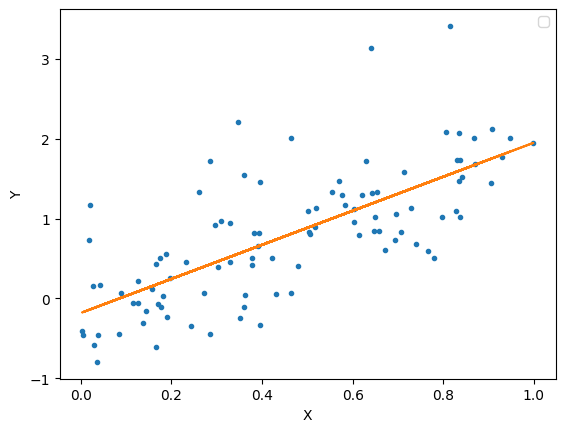

In [ ]:
n = 100

def f(x):
    return 2*x-1

#tomo las muestras aleatorias
X = np.random.uniform(0,1,n)
Z = stats.skewnorm.rvs(a=10, size=n)
Y = f(X) + Z



def get_beta_hat(X, y):
    # Calcular los coeficientes beta_hat = (X^T * X)^-1 * X^T * y (inv = ^-1)
    beta_hat =  np.linalg.inv(X.T @ X) @ X.T @ y # @ es el operador para multiplicación de matrices
    return beta_hat
# Ajuste lineal por cuadrados mínimos
X_intercept = np.column_stack((np.ones_like(X),X)) #armo la matriz de diseño FORMULA: Y = b0 + b1*X OBLIGATORIO

#5a practica 3
b0, b1 = np.linalg.inv(X_intercept.T @ X_intercept) @ X_intercept.T @ Y #obtengo los estimadores del ajuste lineal por cuadrados mínimos

plt.plot(X, Y,'.')
plt.plot(X, b0 + b1 * X)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## b) Repetir el paso anterior $m=30$ veces para obtener $m$ pares de coeficientes $\beta_0$ y $\beta_1$, es decir, $m$ samples de $\hat\beta_0$ y $m$ samples de $\hat\beta_1$. ¿Diríamos que estas distribuciones empíricas son normales? Hacer histogramas para comprobarlo.

0.1937455776006013
-0.004363005075676145


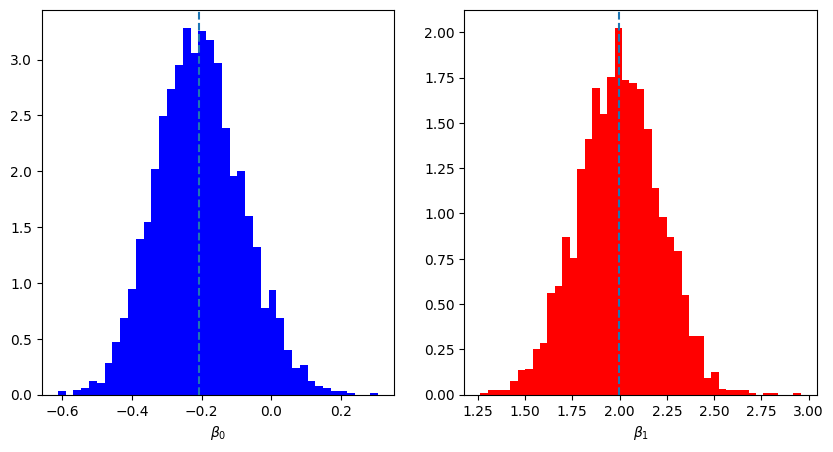

In [ ]:
beta_0 = []
beta_1 = []

for i in range(3000):

  X = np.random.uniform(0,1,n)
  Z = stats.skewnorm.rvs(a=10, size=n)
  Y = f(X) + Z

  X_intercept = np.column_stack((np.ones_like(X),X)) # Paso obligatorio
  b0, b1 = np.linalg.inv(X_intercept.T @ X_intercept) @ X_intercept.T @ Y

  beta_0.append(b0)
  beta_1.append(b1)

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10,5))
ax1.hist(beta_0,bins='auto',color='b',density=True)
ax1.axvline(np.median(beta_0),ls='--')
ax1.set_xlabel(r'$\beta_0$')
ax2.hist(beta_1,bins='auto',color='r',density=True)
ax2.set_xlabel(r'$\beta_1$')
ax2.axvline(np.median(beta_1),ls='--')

print(stats.skew(beta_0))
print(stats.skew(beta_1))

# Ejercicio 3

Modelemos la cantidad de likes diarios que recibe un posteo en Instagram los
30 días posteriores a su publicación. Para eso, consideramos muestras
$(x_1,y_1),\ldots,(x_n,y_n)$ de las variables aleatorias
$X$, los días desde el posteo, que toma valores entre 0 y 30, y $Y$,
la cantidad de likes por día, que es un proceso de Poisson que debe reflejar
de
manera razonable el fenómeno (por ejemplo, los primeros días se
dan muchos likes y después van decayendo en el tiempo).

## a) Generar muestras sintéticas $x=(x_1,\ldots,x_n)$, $y=(y_1,\ldots,y_n)$ para $n = 100$. Graficar $y$ vs $x$.

Text(0, 0.5, 'likes')

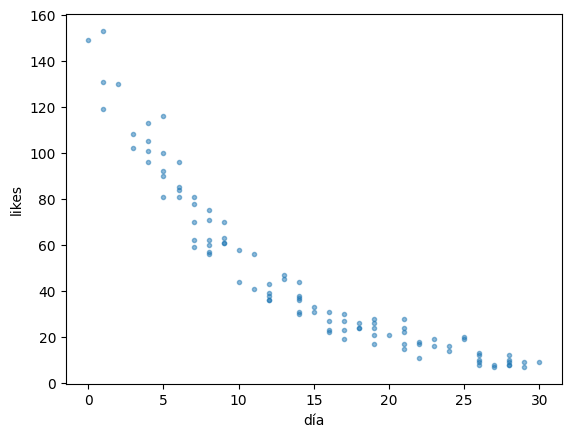

In [ ]:
X_poisson = np.random.randint(0,31,100) # Una distribución uniforme de días (enteros) entre 0 y 30 
#(¿qué pasa si uso una distribución distinta para generar estas muestras?)
intercept = np.ones(X_poisson.shape)
X_poisson_with_intercept = np.column_stack((intercept,X_poisson))


#La idea es ir jugando con estos parámetros hasta obtener algo que tenga sentido de acuerdo al problema.
true_beta = np.array([5,-0.1]) 

 # Exponencial para que tenga una forma del estilo del problema que quiero modelar. 
 # Y casualmente también es la función de vínculo canónica de la distribución Poisson
mu = np.exp(np.dot(X_poisson_with_intercept,true_beta)) # mu = exp(b0 + b1*X)

Y_poisson = np.random.poisson(mu,size=100) # Genero los likes diarios

fig,ax = plt.subplots()
ax.plot(X_poisson,Y_poisson,'.',alpha=0.5)
ax.set_xlabel('día')
ax.set_ylabel('likes')

## b) Proponer el Modelo Lineal Generalizado de Poisson y encontrar estimaciones puntuales para los parámetros de regresión $\beta$.

Propongo el modelo:
$$Y \sim Poisson(\mu) $$
$$ \eta = \log(\mu) = \beta_0 + \beta_1X $$

Como vimos muchas veces, Poisson es una distribución de la familia exponencial con $\theta = \log(\mu)$, $\kappa(\theta) = \mu = e^{\theta}$ y $\phi = 1$

La likelihood es $$ \mathcal{L}(\mu) = \prod_{i=1}^{n}a(y) e^{y_i\log(\mu) -\mu}$$

donde $\mu = \mu(\beta_0,\beta_1) = e^{\beta_0 + \beta_1x_i}$. Entonces maximizar $\mathcal{L}(\mu)$ es lo mismo que minimizar $-\log(\mathcal{L}(\mu)) $ y eso es lo que hago en el código.

b0 =  5.004281390914576
b1 =  -0.10009388574005945


Text(0, 0.5, 'likes')

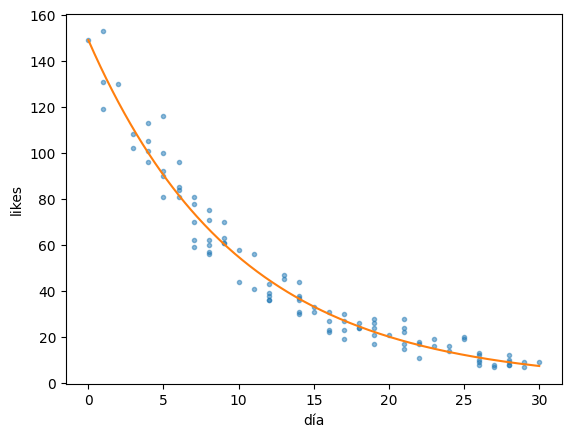

In [ ]:
#usar este para Poisson (fijarse que es -log(L) y no log(L))

def neg_log_likelihood_poisson(beta, X, Y):
    mu_ = np.exp(np.dot(X, beta))
    return -np.sum(Y*np.log(mu_) - mu_)


initial_beta = np.zeros(X_poisson_with_intercept.shape[1])
res_poisson = minimize(neg_log_likelihood_poisson, initial_beta, args=(X_poisson_with_intercept, Y_poisson))
#neg_log_likelihood_poisson is the function to be minimized.
#initial_beta is the initial guess for the coefficients.
#args=(X_poisson_with_intercept, Y_poisson) passes additional arguments to neg_log_likelihood_poisson. 
# Here, X_poisson_with_intercept is the design matrix (features including the intercept), and Y_poisson is the target variable (count data).

b0 = res_poisson.x[0]
b1 = res_poisson.x[1]

print('b0 = ', b0)
print('b1 = ', b1)

x_range_poisson = np.linspace(X_poisson.min(), X_poisson.max(), 300)
poisson_fit = np.exp(b0 + b1 * x_range_poisson)

fig,ax = plt.subplots()
ax.plot(X_poisson,Y_poisson,'.',alpha=0.5)
ax.plot(x_range_poisson,poisson_fit)
ax.set_xlabel('día')
ax.set_ylabel('likes')

## c) Determinar el error estándar de cada parámetro de regresión.

Para esto necesito obtener la matriz de Fischer de la distribución:

$$I = \frac{1}{\phi}X^TWX \hspace{1cm}\text{ con }W = \text{diag}(\frac{1}{V(\mu_i)(d\eta_i/d\mu_i)^2}) $$

En nuestro caso:
$$\phi = 1 $$

$$ V(\mu) = \mu $$

$$ \frac{d\eta}{d\mu} = \frac{d(\log(\mu))}{d\mu} = \frac{1}{\mu}$$

por lo tanto $$I = X^TWX \hspace{1cm}W = \text{diag}(\mu_i) = \text{diag}(e^{\beta_0 + \beta_1x_i}) $$

Finalmente, la matriz de covarianza es $I^{-1}$ y su diagonal, las varianzas respectivas de $\beta_0$ y $\beta_1$:

In [ ]:
mu = np.exp(X_poisson_with_intercept@res_poisson.x)
W = np.diag(mu)
I = X_poisson_with_intercept.T@W@X_poisson_with_intercept
cov_matrix = inv(I)
cov_matrix

array([[ 5.95418140e-04, -4.30542003e-05],
       [-4.30542003e-05,  4.85058050e-06]])

In [ ]:
se_b0 = np.sqrt(cov_matrix[0,0])
se_b1 = np.sqrt(cov_matrix[1,1])
print("se(b0) =",se_b0)
print("se(b1) =",se_b1)

se(b0) = 0.024401191368174265
se(b1) = 0.0022024033461994063


Text(0, 0.5, 'likes')

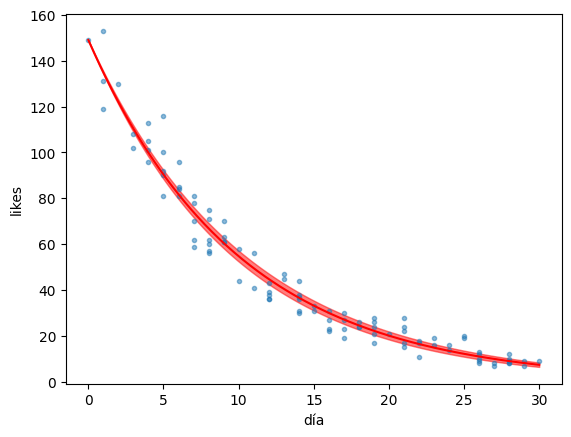

In [ ]:
fig, ax = plt.subplots()
ax.plot(X_poisson,Y_poisson,'.',alpha=0.5)

mu_alto = np.exp(b0 + (b1 + se_b1 *1.96) * x_range_poisson)
mu_bajo = np.exp(b0 + (b1 - se_b1 *1.96) * x_range_poisson)
ax.plot(x_range_poisson,poisson_fit,'red')
ax.fill_between(x_range_poisson, mu_bajo, mu_alto, alpha=0.5,color = 'red')
ax.set_xlabel('día')
ax.set_ylabel('likes')